<a href="https://colab.research.google.com/github/tekassh1/AI-Systems/blob/main/Lab6_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

drive.mount("/content/drive")

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Colab Datasets/diabetes.csv')
target_name = 'Outcome'

df.dropna();

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

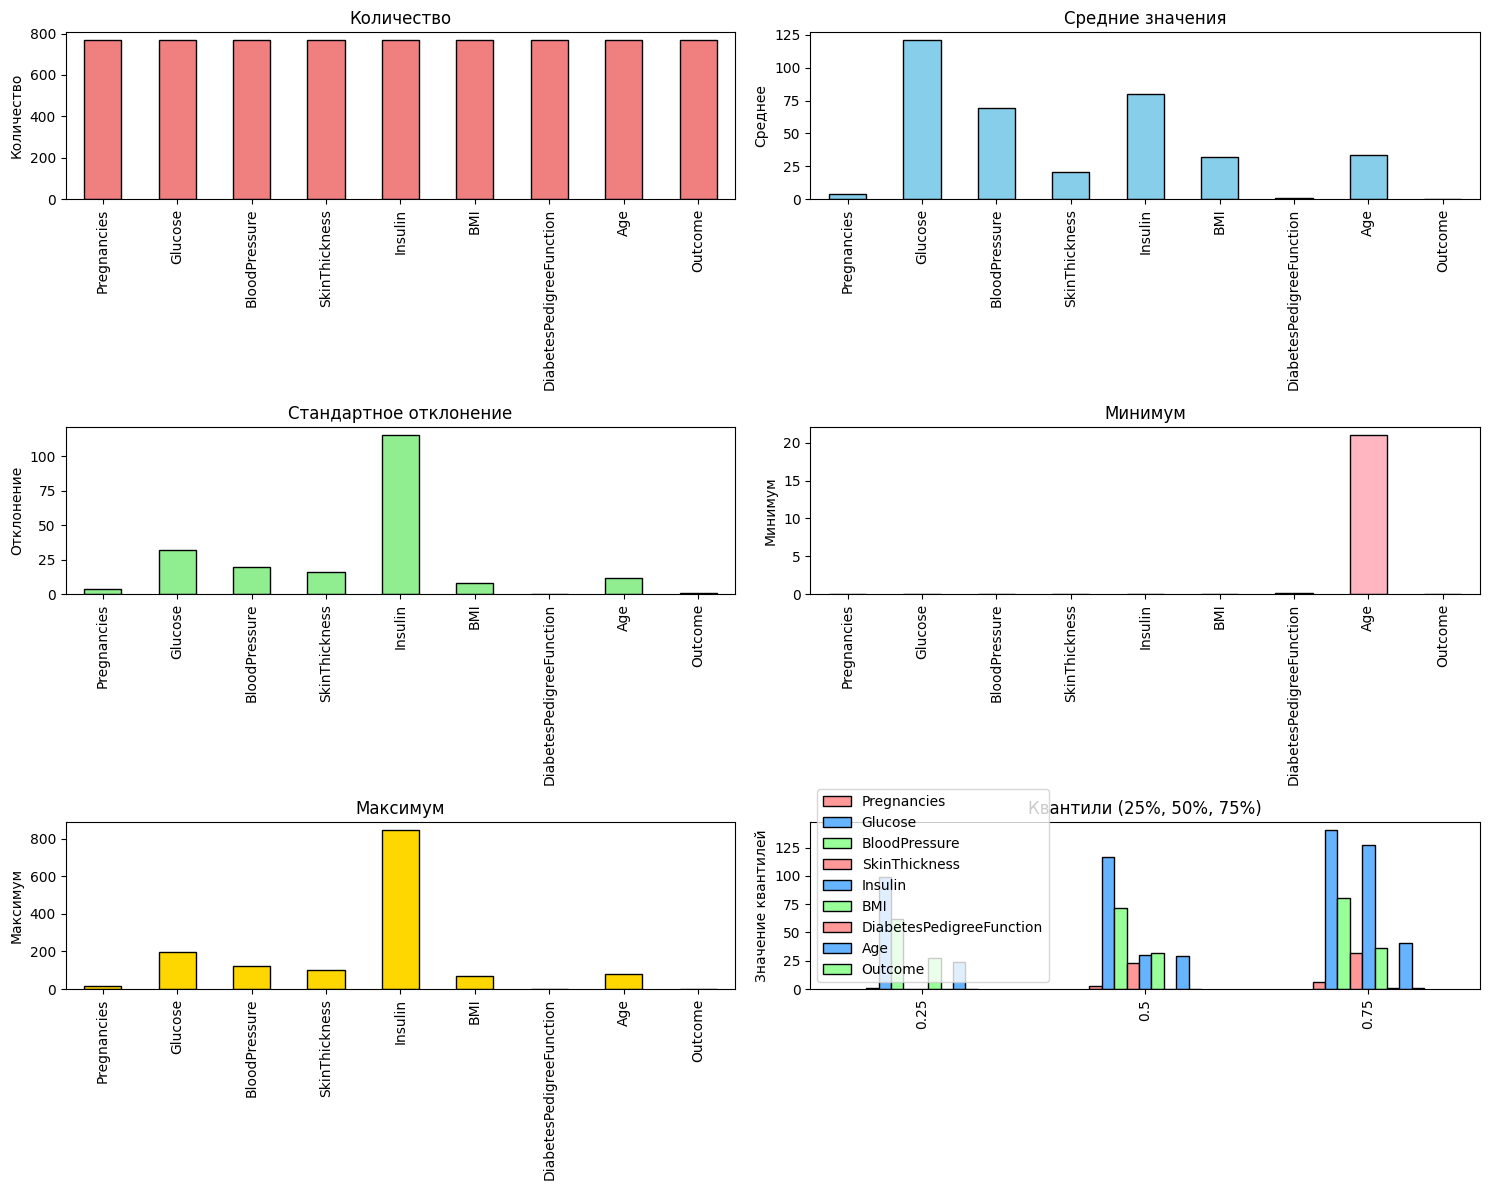

In [11]:
# Show stats

stats = df.describe()

print(stats)

fig, axs = plt.subplots(3, 2, figsize=(15, 12))

count_values = df.count()
count_values.plot(kind='bar', ax=axs[0, 0], color='lightcoral', edgecolor='black')
axs[0, 0].set_title('Количество')
axs[0, 0].set_ylabel('Количество')

mean_values = df.mean()
mean_values.plot(kind='bar', ax=axs[0, 1], color='skyblue', edgecolor='black')
axs[0, 1].set_title('Средние значения')
axs[0, 1].set_ylabel('Среднее')

std_values = df.std()
std_values.plot(kind='bar', ax=axs[1, 0], color='lightgreen', edgecolor='black')
axs[1, 0].set_title('Стандартное отклонение')
axs[1, 0].set_ylabel('Отклонение')

min_values = df.min()
min_values.plot(kind='bar', ax=axs[1, 1], color='lightpink', edgecolor='black')
axs[1, 1].set_title('Минимум')
axs[1, 1].set_ylabel('Минимум')

max_values = df.max()
max_values.plot(kind='bar', ax=axs[2, 0], color='gold', edgecolor='black')
axs[2, 0].set_title('Максимум')
axs[2, 0].set_ylabel('Максимум')

quantiles = [0.25, 0.5, 0.75]
df_quantiles = df.quantile(quantiles)

df_quantiles.plot(kind='bar', ax=axs[2, 1], color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
axs[2, 1].set_title('Квантили (25%, 50%, 75%)')
axs[2, 1].set_ylabel('Значение квантилей')

plt.tight_layout()
plt.show()

In [3]:
# Normalize and split dataset
df = (df - df.min()) / (df.max() - df.min())

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = target_name), df[target_name], test_size=0.2, random_state=42)

In [17]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def log_loss(self, y_true, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def gradient_descent(self, X, y):
        m = len(y)
        predictions = self.sigmoid(X @ self.weights)
        error = predictions - y

        gradient = (X.T @ error) / m
        self.weights -= self.learning_rate * gradient

    def newton_method(self, X, y):
        predictions = self.sigmoid(X @ self.weights)
        gradient = np.dot(X.T, predictions - y)
        D = np.diag(predictions * (1 - predictions))
        H = np.dot(np.dot(X.T, D), X)
        self.weights -= np.linalg.inv(H).dot(gradient)

    def fit(self, X, y, method='newton'):
        X = np.insert(X, 0, 1, axis = 1)
        n_features = X.shape[1]

        self.weights = np.zeros(n_features)

        for i in range(self.n_iterations):
            if method == 'newton':
                self.newton_method(X, y)
            elif method == 'gradient':
                self.gradient_descent(X, y)
            else:
                raise ValueError("Invalid method. Use 'newton' or 'gradient'.")

            if (i + 1) % 100 == 0:
                y_pred = self.predict_proba(X)
                loss = self.log_loss(y, y_pred)
                print(f'Iteration {i+1}, Loss: {loss}')

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)

    def predict(self, X, threshold=0.5):
        X = np.insert(X, 0, 1, axis = 1)
        return (self.predict_proba(X) >= threshold).astype(int)

def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-Score: {f1:.2f}')

print("Gradien descent, 1000 iterations, step = 0.1:")
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train, method='gradient')
predictions = model.predict(X_test)
print_metrics(y_test, predictions)

print("Gradien descent, 3000 iterations, step = 0.1:")
model = LogisticRegression(learning_rate=0.1, n_iterations=3000)
model.fit(X_train, y_train, method='gradient')
predictions = model.predict(X_test)
print_metrics(y_test, predictions)

print("Newton method, 1000 iterations")
model = LogisticRegression(n_iterations=1000)
model.fit(X_train, y_train, method='newton')
predictions = model.predict(X_test)
print_metrics(y_test, predictions)

Gradien descent, 1000 iterations, step = 0.1:
Iteration 100, Loss: 0.6409980220112462
Iteration 200, Loss: 0.6259021535056747
Iteration 300, Loss: 0.6129448898308973
Iteration 400, Loss: 0.601740776074101
Iteration 500, Loss: 0.5919790309048067
Iteration 600, Loss: 0.5834099052766876
Iteration 700, Loss: 0.5758331134312697
Iteration 800, Loss: 0.5690878660447874
Iteration 900, Loss: 0.5630446509119099
Iteration 1000, Loss: 0.55759863332239
Accuracy: 0.70
Precision: 0.67
Recall: 0.33
F1-Score: 0.44
Gradien descent, 3000 iterations, step = 0.1:
Iteration 100, Loss: 0.6409980220112462
Iteration 200, Loss: 0.6259021535056747
Iteration 300, Loss: 0.6129448898308973
Iteration 400, Loss: 0.601740776074101
Iteration 500, Loss: 0.5919790309048067
Iteration 600, Loss: 0.5834099052766876
Iteration 700, Loss: 0.5758331134312697
Iteration 800, Loss: 0.5690878660447874
Iteration 900, Loss: 0.5630446509119099
Iteration 1000, Loss: 0.55759863332239
Iteration 1100, Loss: 0.5526644420534552
Iteration 12